# ML Earnings Velocity Tracker & Goal Achievement Predictor

This notebook implements an ML system to predict driver goal achievement based on real-time earnings velocity data.

**Phases:**
1. Data Preparation & EDA
2. Model Training & Evaluation
3. Real-Time Prediction System
4. Historical Pattern Analysis

## Phase 1: Data Preparation & EDA

### Step 1: Load and Explore Datasets

In [69]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [70]:
# Load all datasets
print("Loading datasets...")

drivers_df = pd.read_csv('data/drivers/drivers.csv')
trips_df = pd.read_csv('data/trips/trips.csv')
driver_goals_df = pd.read_csv('data/earnings/driver_goals.csv')
earnings_velocity_log_df = pd.read_csv('data/earnings/earnings_velocity_log.csv')
trip_summaries_df = pd.read_csv('data/processed_outputs/trip_summaries.csv')
flagged_moments_df = pd.read_csv('data/processed_outputs/flagged_moments.csv')

print(f"✓ Drivers: {drivers_df.shape}")
print(f"✓ Trips: {trips_df.shape}")
print(f"✓ Driver Goals: {driver_goals_df.shape}")
print(f"✓ Earnings Velocity Log: {earnings_velocity_log_df.shape}")
print(f"✓ Trip Summaries: {trip_summaries_df.shape}")
print(f"✓ Flagged Moments: {flagged_moments_df.shape}")

Loading datasets...
✓ Drivers: (210, 8)
✓ Trips: (220, 12)
✓ Driver Goals: (210, 12)
✓ Earnings Velocity Log: (221, 11)
✓ Trip Summaries: (220, 13)
✓ Flagged Moments: (208, 12)


In [71]:
# Explore driver data
print("=" * 60)
print("DRIVER DATA")
print("=" * 60)
print("\nFirst few rows:")
display(drivers_df.head())

print("\nData types and missing values:")
print(drivers_df.info())

print("\nSummary statistics:")
display(drivers_df.describe())

DRIVER DATA

First few rows:


,driver_id,name,city,shift_preference,avg_hours_per_day,avg_earnings_per_hour,experience_months,rating
0,DRV001,Alex Kumar,Mumbai,morning,7.5,185,18,4.8
1,DRV002,Priya Singh,Bangalore,evening,8.2,195,24,4.9
2,DRV003,Rajesh Patel,Delhi,full_day,9.5,175,36,4.7
3,DRV004,Meera Sharma,Pune,morning,6.8,180,12,4.6
4,DRV005,Vikram Reddy,Hyderabad,afternoon,7.0,190,28,4.8



Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   driver_id              210 non-null    object 
 1   name                   210 non-null    object 
 2   city                   210 non-null    object 
 3   shift_preference       210 non-null    object 
 4   avg_hours_per_day      210 non-null    float64
 5   avg_earnings_per_hour  210 non-null    int64  
 6   experience_months      210 non-null    int64  
 7   rating                 210 non-null    float64
dtypes: float64(2), int64(2), object(4)
memory usage: 13.3+ KB
None

Summary statistics:


,avg_hours_per_day,avg_earnings_per_hour,experience_months,rating
count,210.000000,210.000000,210.000000,210.000000
mean,7.727619,187.309524,28.052381,4.702857
std,0.958168,10.498777,12.060141,0.166275
min,6.000000,170.000000,8.000000,4.400000
25%,6.900000,178.250000,17.250000,4.600000
50%,7.900000,186.000000,28.000000,4.700000
75%,8.475000,195.750000,38.000000,4.800000
max,9.500000,205.000000,48.000000,5.000000


In [72]:
# Explore earnings velocity log
print("=" * 60)
print("EARNINGS VELOCITY LOG")
print("=" * 60)
print("\nFirst few rows:")
display(earnings_velocity_log_df.head(10))

print("\nData quality check:")
print(earnings_velocity_log_df.info())

print("\nVelocity statistics:")
display(earnings_velocity_log_df[['current_velocity', 'target_velocity', 'velocity_delta', 
                                   'cumulative_earnings', 'elapsed_hours']].describe())

print("\nForecast status distribution:")
print(earnings_velocity_log_df['forecast_status'].value_counts())

EARNINGS VELOCITY LOG

First few rows:


,log_id,driver_id,date,timestamp,cumulative_earnings,elapsed_hours,current_velocity,target_velocity,velocity_delta,trips_completed,forecast_status
0,VEL001,DRV147,2024-02-06,07:03:00,145,0.55,263.64,175.0,88.64,1,ahead
1,VEL002,DRV028,2024-02-06,07:38:00,365,1.47,248.30,175.0,73.30,2,ahead
2,VEL003,DRV162,2024-02-06,08:15:00,540,2.08,259.62,175.0,84.62,3,ahead
3,VEL004,DRV195,2024-02-06,08:52:00,738,2.87,257.14,175.0,82.14,4,ahead
4,VEL005,DRV018,2024-02-06,09:42:00,996,3.70,269.19,175.0,94.19,5,ahead
5,VEL006,DRV040,2024-02-06,10:28:00,1178,4.47,263.53,175.0,88.53,6,ahead
6,VEL007,DRV096,2024-02-06,11:15:00,1423,5.25,271.05,175.0,96.05,7,ahead
7,VEL008,DRV182,2024-02-06,17:58:00,312,0.97,321.65,200.0,121.65,1,ahead
8,VEL009,DRV163,2024-02-06,18:42:00,580,2.20,263.64,200.0,63.64,2,ahead
9,VEL010,DRV010,2024-02-06,19:35:00,925,3.58,258.38,200.0,58.38,3,ahead



Data quality check:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   log_id               221 non-null    object 
 1   driver_id            221 non-null    object 
 2   date                 221 non-null    object 
 3   timestamp            221 non-null    object 
 4   cumulative_earnings  221 non-null    int64  
 5   elapsed_hours        221 non-null    float64
 6   current_velocity     221 non-null    float64
 7   target_velocity      221 non-null    float64
 8   velocity_delta       221 non-null    float64
 9   trips_completed      221 non-null    int64  
 10  forecast_status      221 non-null    object 
dtypes: float64(4), int64(2), object(5)
memory usage: 19.1+ KB
None

Velocity statistics:


,current_velocity,target_velocity,velocity_delta,cumulative_earnings,elapsed_hours
count,221.000000,221.000000,221.000000,221.000000,221.000000
mean,450.800271,184.338054,266.462217,1211.420814,4.162805
std,500.108251,12.071504,500.522257,680.722089,2.209072
min,26.230000,157.140000,-174.680000,145.000000,0.500000
25%,165.670000,175.000000,-23.230000,658.000000,2.080000
50%,269.180000,183.000000,94.190000,1170.000000,4.040000
75%,518.090000,195.000000,346.090000,1769.000000,6.060000
max,3568.520000,205.000000,3391.520000,2500.000000,7.930000



Forecast status distribution:
forecast_status
ahead       157
at_risk      57
on_track      7
Name: count, dtype: int64


In [73]:
# Explore driver goals
print("=" * 60)
print("DRIVER GOALS")
print("=" * 60)
print("\nFirst few rows:")
display(driver_goals_df.head())

print("\nGoal achievement status:")
print(driver_goals_df['status'].value_counts())

print("\nGoal statistics:")
display(driver_goals_df[['target_earnings', 'target_hours', 'current_earnings', 
                         'current_hours']].describe())

# Calculate actual goal achievement rate
print("\nGoal achievement rate:")
achieved = (driver_goals_df['status'] == 'achieved').sum()
total = len(driver_goals_df)
print(f"Achievement Rate: {achieved}/{total} = {achieved/total*100:.1f}%")

DRIVER GOALS

First few rows:


,goal_id,driver_id,date,shift_start_time,shift_end_time,target_earnings,target_hours,current_earnings,current_hours,status,earnings_velocity,goal_completion_forecast
0,GOAL001,DRV001,2024-02-06,06:30:00,14:30:00,1400,8.0,1423,7.5,achieved,189.73,on_track
1,GOAL002,DRV002,2024-02-06,17:00:00,23:00:00,1200,6.0,925,3.5,in_progress,264.29,on_track
2,GOAL003,DRV003,2024-02-06,07:30:00,17:30:00,1750,10.0,1148,5.2,in_progress,220.77,on_track
3,GOAL004,DRV004,2024-02-06,06:00:00,13:00:00,1100,7.0,403,2.3,in_progress,175.22,at_risk
4,GOAL005,DRV005,2024-02-06,13:30:00,20:30:00,1300,7.0,546,2.8,in_progress,195.00,on_track



Goal achievement status:
status
at_risk        72
achieved       71
in_progress    67
Name: count, dtype: int64

Goal statistics:


,target_earnings,target_hours,current_earnings,current_hours
count,210.000000,210.000000,210.000000,210.000000
mean,1426.128571,8.031905,806.776190,4.674762
std,200.572930,1.115434,389.649152,1.878124
min,1100.000000,6.000000,211.000000,1.500000
25%,1245.250000,7.000000,462.250000,2.925000
50%,1408.500000,8.100000,806.500000,4.700000
75%,1597.500000,8.975000,1110.000000,6.300000
max,1800.000000,10.000000,1771.000000,8.000000



Goal achievement rate:
Achievement Rate: 71/210 = 33.8%


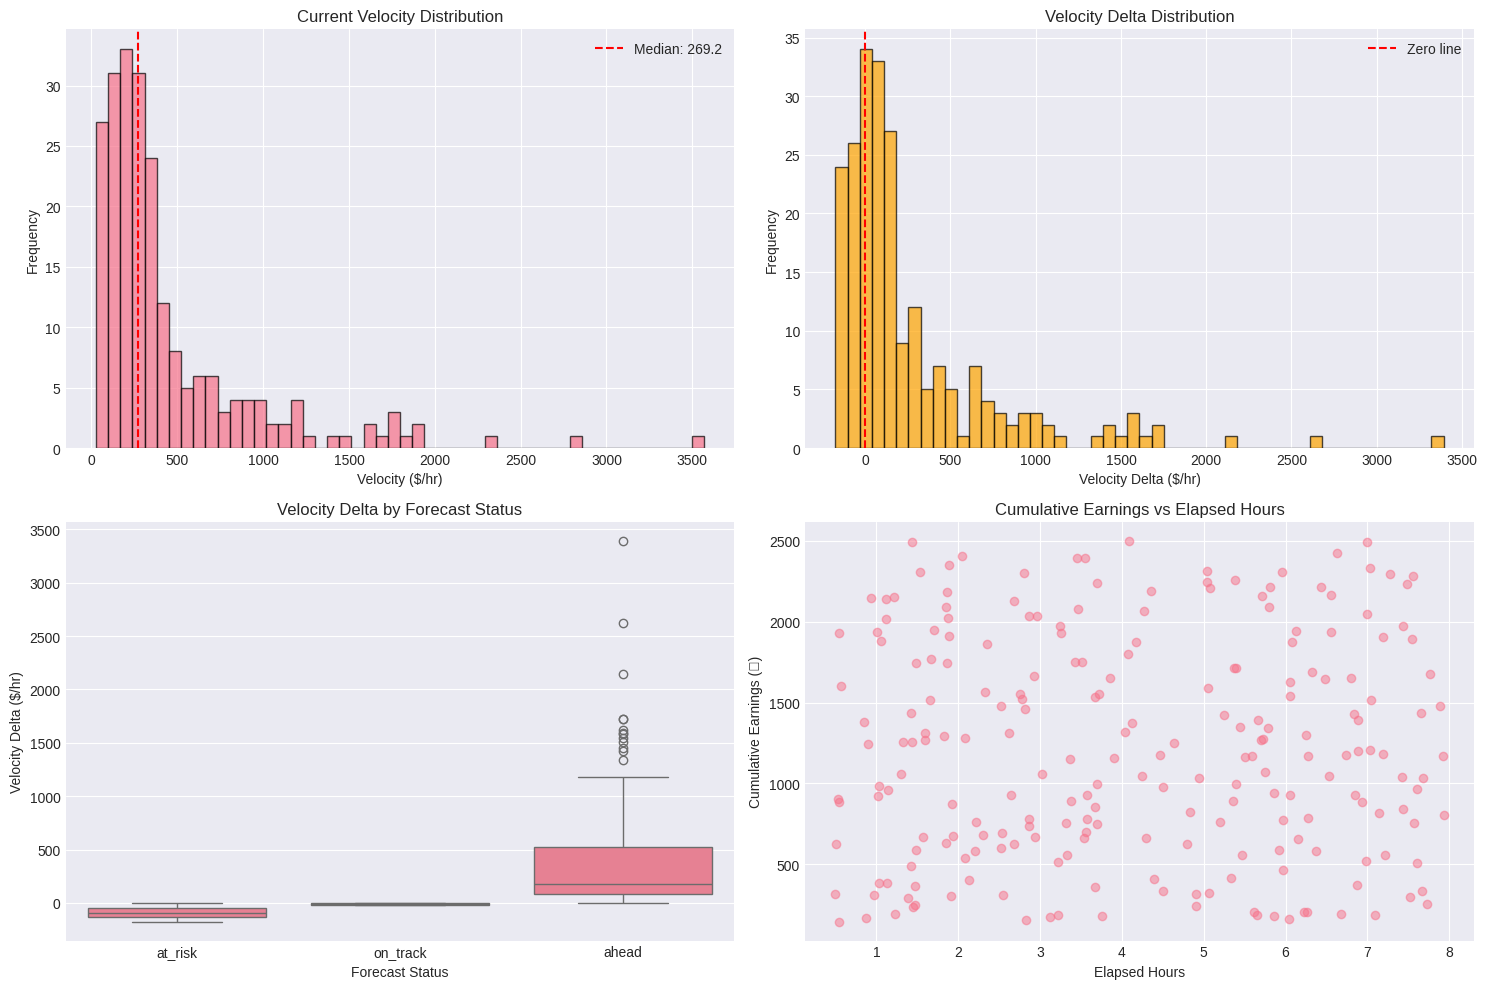


Key observations:
- Velocity ranges from 26.2 to 3568.5 $/hr
- Extreme velocities (>700 $/hr) present: 40 checkpoints
- Negative velocity deltas: 64 checkpoints (29.0%)


In [74]:
# Visualize velocity distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Current velocity distribution
axes[0, 0].hist(earnings_velocity_log_df['current_velocity'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Current Velocity Distribution')
axes[0, 0].set_xlabel('Velocity ($/hr)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(earnings_velocity_log_df['current_velocity'].median(), 
                   color='red', linestyle='--', label=f'Median: {earnings_velocity_log_df["current_velocity"].median():.1f}')
axes[0, 0].legend()

# Velocity delta distribution
axes[0, 1].hist(earnings_velocity_log_df['velocity_delta'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_title('Velocity Delta Distribution')
axes[0, 1].set_xlabel('Velocity Delta ($/hr)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(0, color='red', linestyle='--', label='Zero line')
axes[0, 1].legend()

# Forecast status by velocity delta
status_order = ['at_risk', 'on_track', 'ahead']
sns.boxplot(data=earnings_velocity_log_df, x='forecast_status', y='velocity_delta', 
            order=status_order, ax=axes[1, 0])
axes[1, 0].set_title('Velocity Delta by Forecast Status')
axes[1, 0].set_xlabel('Forecast Status')
axes[1, 0].set_ylabel('Velocity Delta ($/hr)')

# Cumulative earnings over time
axes[1, 1].scatter(earnings_velocity_log_df['elapsed_hours'], 
                   earnings_velocity_log_df['cumulative_earnings'], alpha=0.5)
axes[1, 1].set_title('Cumulative Earnings vs Elapsed Hours')
axes[1, 1].set_xlabel('Elapsed Hours')
axes[1, 1].set_ylabel('Cumulative Earnings (₹)')

plt.tight_layout()
plt.show()

print("\nKey observations:")
print(f"- Velocity ranges from {earnings_velocity_log_df['current_velocity'].min():.1f} to {earnings_velocity_log_df['current_velocity'].max():.1f} $/hr")
print(f"- Extreme velocities (>700 $/hr) present: {(earnings_velocity_log_df['current_velocity'] > 700).sum()} checkpoints")
print(f"- Negative velocity deltas: {(earnings_velocity_log_df['velocity_delta'] < 0).sum()} checkpoints ({(earnings_velocity_log_df['velocity_delta'] < 0).sum()/len(earnings_velocity_log_df)*100:.1f}%)")

### Step 2: Create Master Training Dataset

Join all data sources to create a unified dataset for training.

In [75]:
# Prepare driver goals with target variable
print("Preparing driver goals with target variable...")

# Create binary goal_achieved variable
driver_goals_df['goal_achieved'] = (driver_goals_df['status'] == 'achieved').astype(int)

# Calculate final achievement metrics
driver_goals_df['achievement_ratio'] = driver_goals_df['current_earnings'] / driver_goals_df['target_earnings']
driver_goals_df['hours_ratio'] = driver_goals_df['current_hours'] / driver_goals_df['target_hours']

print(f"\nGoal achievement summary:")
print(driver_goals_df['goal_achieved'].value_counts())
print(f"\nAchievement ratio stats:")
display(driver_goals_df['achievement_ratio'].describe())

# Keep only necessary columns for merging
driver_goals_clean = driver_goals_df[['goal_id', 'driver_id', 'date', 'target_earnings', 
                                       'target_hours', 'goal_achieved', 'achievement_ratio']].copy()

Preparing driver goals with target variable...

Goal achievement summary:
goal_achieved
0    139
1     71
Name: count, dtype: int64

Achievement ratio stats:


count    210.000000
mean       0.567375
std        0.259327
min        0.125905
25%        0.316852
50%        0.581448
75%        0.787580
max        1.016429
Name: achievement_ratio, dtype: float64

In [76]:
# Merge velocity log with driver goals
print("Merging velocity log with driver goals...")

# Merge on driver_id and date
master_df = earnings_velocity_log_df.merge(
    driver_goals_clean,
    on=['driver_id', 'date'],
    how='left'
)

print(f"Shape after merge: {master_df.shape}")
print(f"Missing target values: {master_df['goal_achieved'].isna().sum()}")

# Merge with driver profiles
print("\nAdding driver profile features...")
master_df = master_df.merge(
    drivers_df[['driver_id', 'city', 'shift_preference', 'avg_hours_per_day', 
                'avg_earnings_per_hour', 'experience_months', 'rating']],
    on='driver_id',
    how='left'
)

print(f"Shape after adding driver features: {master_df.shape}")
print(f"\nMaster dataset columns:")
print(master_df.columns.tolist())

Merging velocity log with driver goals...
Shape after merge: (235, 16)
Missing target values: 10

Adding driver profile features...
Shape after adding driver features: (235, 22)

Master dataset columns:
['log_id', 'driver_id', 'date', 'timestamp', 'cumulative_earnings', 'elapsed_hours', 'current_velocity', 'target_velocity', 'velocity_delta', 'trips_completed', 'forecast_status', 'goal_id', 'target_earnings', 'target_hours', 'goal_achieved', 'achievement_ratio', 'city', 'shift_preference', 'avg_hours_per_day', 'avg_earnings_per_hour', 'experience_months', 'rating']


In [77]:
# Aggregate trip features per driver
print("Aggregating trip features...")

trip_agg = trips_df.groupby('driver_id').agg({
    'surge_multiplier': ['mean', 'max'],
    'duration_min': 'mean',
    'distance_km': 'mean',
    'fare': 'mean'
}).reset_index()

trip_agg.columns = ['driver_id', 'avg_surge', 'max_surge', 'avg_duration_min', 
                    'avg_distance_km', 'avg_fare']

# Merge trip features
master_df = master_df.merge(trip_agg, on='driver_id', how='left')

print(f"Shape after adding trip features: {master_df.shape}")

# Aggregate sensor/quality features
print("\nAggregating sensor and quality features...")

if 'driver_id' in trip_summaries_df.columns:
    quality_agg = trip_summaries_df.groupby('driver_id').agg({
        'motion_events_count': 'sum',
        'audio_events_count': 'sum',
        'stress_score': 'mean'
    }).reset_index()
    
    quality_agg.columns = ['driver_id', 'total_motion_events', 'total_audio_events', 'avg_stress_score']
    
    master_df = master_df.merge(quality_agg, on='driver_id', how='left')
    print(f"Shape after adding quality features: {master_df.shape}")
else:
    print("Quality features not available in expected format, skipping...")

print(f"\nFinal master dataset shape: {master_df.shape}")
print(f"Columns: {len(master_df.columns)}")

Aggregating trip features...
Shape after adding trip features: (235, 27)

Aggregating sensor and quality features...
Shape after adding quality features: (235, 30)

Final master dataset shape: (235, 30)
Columns: 30


### Step 3: Feature Engineering

Create derived features for model training.

In [78]:
# Create feature engineering pipeline
print("Engineering features...")

# 1. Progress metrics
master_df['progress_percent'] = (master_df['cumulative_earnings'] / master_df['target_earnings']) * 100
master_df['hours_progress_percent'] = (master_df['elapsed_hours'] / master_df['target_hours']) * 100
master_df['earnings_gap'] = master_df['target_earnings'] - master_df['cumulative_earnings']

# 2. Time-based features
# Parse timestamp if it's in datetime format
if master_df['timestamp'].dtype == 'object':
    master_df['timestamp'] = pd.to_datetime(master_df['timestamp'], errors='coerce')
    
master_df['hour_of_day'] = pd.to_datetime(master_df['timestamp']).dt.hour
master_df['time_remaining_hours'] = master_df['target_hours'] - master_df['elapsed_hours']

# Shift stage categorization
master_df['shift_stage'] = pd.cut(master_df['hours_progress_percent'], 
                                    bins=[0, 33, 66, 100, float('inf')],
                                    labels=['early', 'mid', 'late', 'overtime'])

# 3. Velocity-based features
master_df['velocity_acceleration'] = master_df['current_velocity'] - master_df['target_velocity']
master_df['required_velocity'] = master_df['earnings_gap'] / master_df['time_remaining_hours'].replace(0, np.nan)

# Velocity volatility using absolute delta
master_df['velocity_volatility'] = abs(master_df['velocity_delta'])

# 4. Efficiency metrics
master_df['trips_per_hour'] = master_df['trips_completed'] / master_df['elapsed_hours'].replace(0, np.nan)
master_df['earnings_per_trip'] = master_df['cumulative_earnings'] / master_df['trips_completed'].replace(0, np.nan)

print(f"\n✓ Created {len([c for c in master_df.columns if c not in earnings_velocity_log_df.columns])} new features")
print(f"✓ Total features: {master_df.shape[1]}")
print(f"✓ Total samples: {master_df.shape[0]}")

Engineering features...

✓ Created 30 new features
✓ Total features: 41
✓ Total samples: 235


In [79]:
# Create rolling features (velocity trends by driver)
print("Creating rolling velocity features...")

# Sort by driver and time
master_df = master_df.sort_values(['driver_id', 'timestamp']).reset_index(drop=True)

# Rolling features within each driver
master_df['velocity_rolling_mean'] = master_df.groupby('driver_id')['current_velocity'].transform(
    lambda x: x.rolling(window=2, min_periods=1).mean()
)

master_df['velocity_rolling_std'] = master_df.groupby('driver_id')['current_velocity'].transform(
    lambda x: x.rolling(window=2, min_periods=1).std()
).fillna(0)

# Lag features (previous checkpoint velocity)
master_df['velocity_lag1'] = master_df.groupby('driver_id')['current_velocity'].shift(1)
master_df['velocity_lag1'] = master_df['velocity_lag1'].fillna(master_df['current_velocity'])

print("✓ Rolling features created")

# One-hot encode categorical features
print("\nEncoding categorical features...")

master_df = pd.get_dummies(master_df, columns=['city', 'shift_preference', 'shift_stage'], 
                           prefix=['city', 'shift', 'stage'], drop_first=False)

print(f"✓ Categorical features encoded")
print(f"✓ Final dataset shape: {master_df.shape}")

Creating rolling velocity features...
✓ Rolling features created

Encoding categorical features...
✓ Categorical features encoded
✓ Final dataset shape: (235, 57)


In [80]:
# Handle missing values and prepare final dataset
print("Preparing final training dataset...")

# Check for missing values
print(f"\nMissing values before cleaning:")
missing_counts = master_df.isnull().sum()
print(missing_counts[missing_counts > 0])

# Fill missing values in numeric columns first
numeric_cols = master_df.select_dtypes(include=[np.number]).columns
master_df[numeric_cols] = master_df[numeric_cols].fillna(0)

# Replace inf values
master_df.replace([np.inf, -np.inf], 0, inplace=True)

# Drop rows with missing target variable (do this AFTER filling other columns)
print(f"\nRows before dropping missing targets: {len(master_df)}")
print(f"Missing values in goal_achieved: {master_df['goal_achieved'].isna().sum()}")
master_df = master_df[master_df['goal_achieved'].notna()].copy()
print(f"Rows after dropping missing targets: {len(master_df)}")

# Final verification - ensure no NaN in target
assert master_df['goal_achieved'].isna().sum() == 0, "Target variable still contains NaN values!"

print(f"\n✓ Dataset cleaned")
print(f"✓ Final shape: {master_df.shape}")
print(f"✓ Target distribution:")
print(master_df['goal_achieved'].value_counts())

Preparing final training dataset...

Missing values before cleaning:
goal_id                   10
target_earnings           10
target_hours              10
goal_achieved             10
achievement_ratio         10
avg_surge                 98
max_surge                 98
avg_duration_min          98
avg_distance_km           98
avg_fare                  98
total_motion_events       98
total_audio_events        98
avg_stress_score          98
progress_percent          10
hours_progress_percent    10
earnings_gap              10
time_remaining_hours      10
required_velocity         10
dtype: int64

Rows before dropping missing targets: 235
Missing values in goal_achieved: 0
Rows after dropping missing targets: 235

✓ Dataset cleaned
✓ Final shape: (235, 57)
✓ Target distribution:
goal_achieved
0.0    172
1.0     63
Name: count, dtype: int64


In [81]:
# Define feature columns
print("Defining feature set...")

# Exclude non-feature columns
exclude_cols = ['log_id', 'driver_id', 'date', 'timestamp', 'goal_id', 
                'goal_achieved', 'achievement_ratio', 'forecast_status',
                'cumulative_earnings', 'target_earnings', 'target_hours']

feature_cols = [col for col in master_df.columns if col not in exclude_cols]

print(f"\n✓ Total features: {len(feature_cols)}")
print(f"\nFeature categories:")
print(f"  - Velocity features: {len([c for c in feature_cols if 'velocity' in c.lower()])}")
print(f"  - Progress features: {len([c for c in feature_cols if 'progress' in c.lower() or 'gap' in c.lower()])}")
print(f"  - Time features: {len([c for c in feature_cols if 'time' in c.lower() or 'hour' in c.lower()])}")
print(f"  - Driver features: {len([c for c in feature_cols if any(x in c for x in ['experience', 'rating', 'avg_'])])}")
print(f"  - City/Shift dummies: {len([c for c in feature_cols if c.startswith(('city_', 'shift_', 'stage_'))])}")

# Display first 20 features
print(f"\nFirst 20 features:")
for i, col in enumerate(feature_cols[:20], 1):
    print(f"  {i}. {col}")

Defining feature set...

✓ Total features: 46

Feature categories:
  - Velocity features: 9
  - Progress features: 3
  - Time features: 8
  - Driver features: 9
  - City/Shift dummies: 16

First 20 features:
  1. elapsed_hours
  2. current_velocity
  3. target_velocity
  4. velocity_delta
  5. trips_completed
  6. avg_hours_per_day
  7. avg_earnings_per_hour
  8. experience_months
  9. rating
  10. avg_surge
  11. max_surge
  12. avg_duration_min
  13. avg_distance_km
  14. avg_fare
  15. total_motion_events
  16. total_audio_events
  17. avg_stress_score
  18. progress_percent
  19. hours_progress_percent
  20. earnings_gap


In [82]:
# Split data into train, validation, and test sets
from sklearn.model_selection import train_test_split

print("Splitting data...")

X = master_df[feature_cols]
y = master_df['goal_achieved']

# Verify no NaN values before splitting
print(f"\nData quality check before split:")
print(f"  NaN in features: {X.isna().any().sum()} columns")
print(f"  NaN in target: {y.isna().sum()} rows")
print(f"  Inf in features: {np.isinf(X.select_dtypes(include=[np.number])).any().sum()} columns")

if y.isna().sum() > 0:
    print(f"\n⚠ Warning: Dropping {y.isna().sum()} rows with NaN target values")
    valid_idx = y.notna()
    X = X[valid_idx]
    y = y[valid_idx]

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\n✓ Train set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"✓ Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"✓ Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nTarget distribution in train set:")
print(y_train.value_counts(normalize=True))
print(f"\nTarget distribution in validation set:")
print(y_val.value_counts(normalize=True))
print(f"\nTarget distribution in test set:")
print(y_test.value_counts(normalize=True))

Splitting data...

Data quality check before split:
  NaN in features: 0 columns
  NaN in target: 0 rows
  Inf in features: 0 columns

✓ Train set: 164 samples (69.8%)
✓ Validation set: 35 samples (14.9%)
✓ Test set: 36 samples (15.3%)

Target distribution in train set:
goal_achieved
0.0    0.731707
1.0    0.268293
Name: proportion, dtype: float64

Target distribution in validation set:
goal_achieved
0.0    0.742857
1.0    0.257143
Name: proportion, dtype: float64

Target distribution in test set:
goal_achieved
0.0    0.722222
1.0    0.277778
Name: proportion, dtype: float64


## Phase 2: Model Training & Evaluation

### Step 4: Train Baseline Models

In [83]:
# Import ML libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, classification_report, 
                             confusion_matrix)
from sklearn.preprocessing import StandardScaler

print("ML libraries imported successfully!")

ML libraries imported successfully!


In [84]:
# Baseline 1: Simple threshold rule
print("=" * 60)
print("BASELINE 1: Simple Threshold Rule")
print("=" * 60)
print("\nRule: 'ahead' if velocity_delta > 0, else 'at_risk'")

# Get velocity_delta from training data
y_train_baseline = (X_train['velocity_delta'] > 0).astype(int)
y_val_baseline = (X_val['velocity_delta'] > 0).astype(int)

# Evaluate on validation set
val_acc = accuracy_score(y_val, y_val_baseline)
val_precision = precision_score(y_val, y_val_baseline, zero_division=0)
val_recall = recall_score(y_val, y_val_baseline, zero_division=0)
val_f1 = f1_score(y_val, y_val_baseline, zero_division=0)

print(f"\nValidation Set Performance:")
print(f"  Accuracy: {val_acc:.4f}")
print(f"  Precision: {val_precision:.4f}")
print(f"  Recall: {val_recall:.4f}")
print(f"  F1-Score: {val_f1:.4f}")

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_baseline))

# Store baseline results
baseline_results = {
    'model': 'Threshold Rule',
    'accuracy': val_acc,
    'precision': val_precision,
    'recall': val_recall,
    'f1': val_f1
}

BASELINE 1: Simple Threshold Rule

Rule: 'ahead' if velocity_delta > 0, else 'at_risk'

Validation Set Performance:
  Accuracy: 0.4857
  Precision: 0.3043
  Recall: 0.7778
  F1-Score: 0.4375

Confusion Matrix:
[[10 16]
 [ 2  7]]


In [85]:
# Baseline 2: Logistic Regression
print("\n" + "=" * 60)
print("BASELINE 2: Logistic Regression")
print("=" * 60)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Train model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_val_pred_lr = lr_model.predict(X_val_scaled)
y_val_prob_lr = lr_model.predict_proba(X_val_scaled)[:, 1]

# Evaluate
lr_acc = accuracy_score(y_val, y_val_pred_lr)
lr_precision = precision_score(y_val, y_val_pred_lr)
lr_recall = recall_score(y_val, y_val_pred_lr)
lr_f1 = f1_score(y_val, y_val_pred_lr)
lr_auc = roc_auc_score(y_val, y_val_prob_lr)

print(f"\nValidation Set Performance:")
print(f"  Accuracy: {lr_acc:.4f}")
print(f"  Precision: {lr_precision:.4f}")
print(f"  Recall: {lr_recall:.4f}")
print(f"  F1-Score: {lr_f1:.4f}")
print(f"  ROC-AUC: {lr_auc:.4f}")

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_lr))

print(f"\nClassification Report:")
print(classification_report(y_val, y_val_pred_lr, target_names=['Not Achieved', 'Achieved']))

# Store results
lr_results = {
    'model': 'Logistic Regression',
    'accuracy': lr_acc,
    'precision': lr_precision,
    'recall': lr_recall,
    'f1': lr_f1,
    'auc': lr_auc
}

print(f"\n✓ Logistic Regression trained successfully!")


BASELINE 2: Logistic Regression



Validation Set Performance:
  Accuracy: 0.7429
  Precision: 0.5000
  Recall: 0.2222
  F1-Score: 0.3077
  ROC-AUC: 0.6709

Confusion Matrix:
[[24  2]
 [ 7  2]]

Classification Report:
              precision    recall  f1-score   support

Not Achieved       0.77      0.92      0.84        26
    Achieved       0.50      0.22      0.31         9

    accuracy                           0.74        35
   macro avg       0.64      0.57      0.57        35
weighted avg       0.70      0.74      0.70        35


✓ Logistic Regression trained successfully!


### Step 5: Train XGBoost/LightGBM Classifier

In [86]:
# Import gradient boosting libraries
try:
    import xgboost as xgb
    xgb_available = True
except ImportError:
    xgb_available = False
    print("XGBoost not available. Installing...")
    
try:
    import lightgbm as lgb
    lgb_available = True
except ImportError:
    lgb_available = False
    print("LightGBM not available. Installing...")

if xgb_available:
    print("✓ XGBoost available")
if lgb_available:
    print("✓ LightGBM available")

LightGBM not available. Installing...
✓ XGBoost available


In [87]:
# Train XGBoost Classifier
print("=" * 60)
print("XGBOOST CLASSIFIER")
print("=" * 60)

if xgb_available:
    # Define XGBoost model with balanced parameters
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    )
    
    # Train model
    print("\nTraining XGBoost...")
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # Predictions
    y_val_pred_xgb = xgb_model.predict(X_val)
    y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]
    
    # Evaluate
    xgb_acc = accuracy_score(y_val, y_val_pred_xgb)
    xgb_precision = precision_score(y_val, y_val_pred_xgb)
    xgb_recall = recall_score(y_val, y_val_pred_xgb)
    xgb_f1 = f1_score(y_val, y_val_pred_xgb)
    xgb_auc = roc_auc_score(y_val, y_val_prob_xgb)
    
    print(f"\nValidation Set Performance:")
    print(f"  Accuracy: {xgb_acc:.4f} (Δ vs LR: {(xgb_acc-lr_acc)*100:+.1f}%)")
    print(f"  Precision: {xgb_precision:.4f}")
    print(f"  Recall: {xgb_recall:.4f}")
    print(f"  F1-Score: {xgb_f1:.4f}")
    print(f"  ROC-AUC: {xgb_auc:.4f}")
    
    print(f"\nConfusion Matrix:")
    print(confusion_matrix(y_val, y_val_pred_xgb))
    
    print(f"\nClassification Report:")
    print(classification_report(y_val, y_val_pred_xgb, target_names=['Not Achieved', 'Achieved']))
    
    # Store results
    xgb_results = {
        'model': 'XGBoost',
        'accuracy': xgb_acc,
        'precision': xgb_precision,
        'recall': xgb_recall,
        'f1': xgb_f1,
        'auc': xgb_auc
    }
    
    print(f"\n✓ XGBoost trained successfully!")
else:
    print("\nXGBoost not available. Please install: pip install xgboost")

XGBOOST CLASSIFIER

Training XGBoost...

Validation Set Performance:
  Accuracy: 0.7714 (Δ vs LR: +2.9%)
  Precision: 0.5714
  Recall: 0.4444
  F1-Score: 0.5000
  ROC-AUC: 0.6838

Confusion Matrix:
[[23  3]
 [ 5  4]]

Classification Report:
              precision    recall  f1-score   support

Not Achieved       0.82      0.88      0.85        26
    Achieved       0.57      0.44      0.50         9

    accuracy                           0.77        35
   macro avg       0.70      0.66      0.68        35
weighted avg       0.76      0.77      0.76        35


✓ XGBoost trained successfully!


FEATURE IMPORTANCE (XGBoost)

Top 20 Most Important Features:


,feature,importance
11,avg_duration_min,0.062189
33,city_Delhi,0.058658
14,total_motion_events,0.044459
44,stage_late,0.044072
10,max_surge,0.038713
32,city_Chennai,0.036972
6,avg_earnings_per_hour,0.036044
15,total_audio_events,0.034140
5,avg_hours_per_day,0.033547
27,velocity_rolling_mean,0.033327


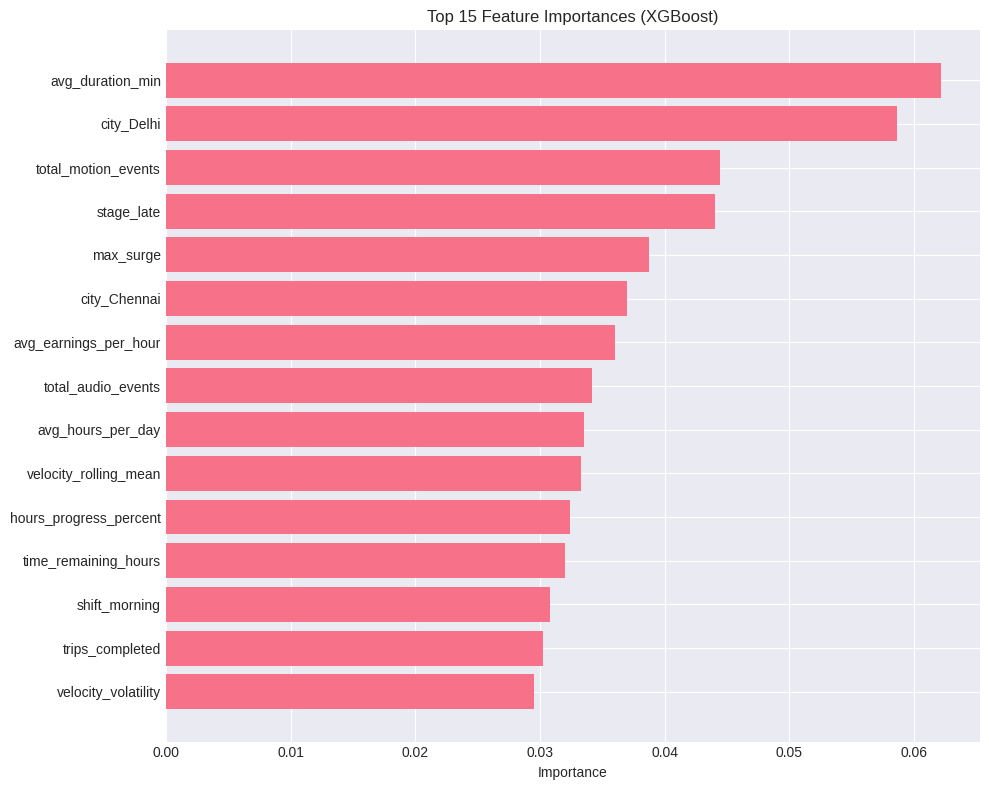


Key features in top 10:
  ✗ velocity_delta: Not in top 10
  ✗ progress_percent: Not in top 10
  ✗ time_remaining_hours: Not in top 10
  ✓ velocity_rolling_mean: Rank #10
  ✗ earnings_gap: Not in top 10


In [88]:
# Feature importance from XGBoost
if xgb_available:
    print("=" * 60)
    print("FEATURE IMPORTANCE (XGBoost)")
    print("=" * 60)
    
    # Get feature importance
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nTop 20 Most Important Features:")
    display(feature_importance.head(20))
    
    # Visualize top 15 features
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance')
    plt.title('Top 15 Feature Importances (XGBoost)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # Check if key features are in top 10
    top_10_features = feature_importance.head(10)['feature'].tolist()
    key_features = ['velocity_delta', 'progress_percent', 'time_remaining_hours', 
                    'velocity_rolling_mean', 'earnings_gap']
    print(f"\nKey features in top 10:")
    for feat in key_features:
        if feat in top_10_features:
            rank = top_10_features.index(feat) + 1
            print(f"  ✓ {feat}: Rank #{rank}")
        else:
            print(f"  ✗ {feat}: Not in top 10")

### Step 6: Train Regression Model for Earnings Prediction

XGBOOST REGRESSOR - Final Earnings Prediction

Training XGBoost Regressor...

Validation Set Performance:
  RMSE: 0.2550
  MAE: 0.2056
  R² Score: 0.0137

Prediction Statistics:
  Actual achievement ratio: 0.534 ± 0.260
  Predicted achievement ratio: 0.505 ± 0.177


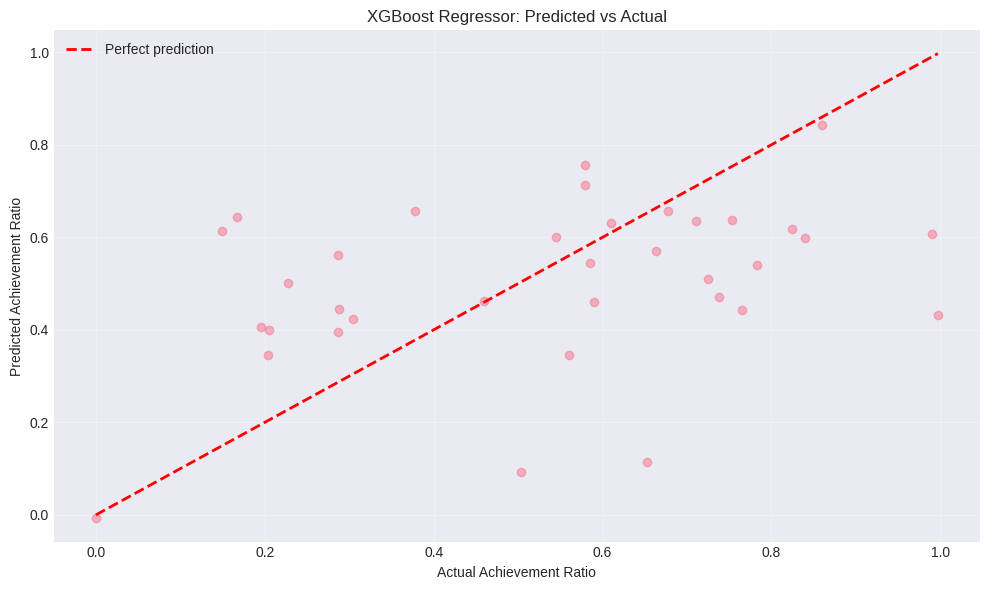


✓ Regressor trained successfully!


In [89]:
# Train XGBoost Regressor for final earnings prediction
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("=" * 60)
print("XGBOOST REGRESSOR - Final Earnings Prediction")
print("=" * 60)

# Prepare target variable: final_earnings / target_earnings ratio
y_train_reg = master_df.loc[X_train.index, 'achievement_ratio']
y_val_reg = master_df.loc[X_val.index, 'achievement_ratio']
y_test_reg = master_df.loc[X_test.index, 'achievement_ratio']

if xgb_available:
    # Define regressor
    xgb_reg = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42
    )
    
    # Train
    print("\nTraining XGBoost Regressor...")
    xgb_reg.fit(
        X_train, y_train_reg,
        eval_set=[(X_val, y_val_reg)],
        verbose=False
    )
    
    # Predictions
    y_val_pred_reg = xgb_reg.predict(X_val)
    
    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_val_reg, y_val_pred_reg))
    mae = mean_absolute_error(y_val_reg, y_val_pred_reg)
    r2 = r2_score(y_val_reg, y_val_pred_reg)
    
    print(f"\nValidation Set Performance:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R² Score: {r2:.4f}")
    
    # Analyze predictions
    print(f"\nPrediction Statistics:")
    print(f"  Actual achievement ratio: {y_val_reg.mean():.3f} ± {y_val_reg.std():.3f}")
    print(f"  Predicted achievement ratio: {y_val_pred_reg.mean():.3f} ± {y_val_pred_reg.std():.3f}")
    
    # Visualize predictions vs actual
    plt.figure(figsize=(10, 6))
    plt.scatter(y_val_reg, y_val_pred_reg, alpha=0.5)
    plt.plot([y_val_reg.min(), y_val_reg.max()], 
             [y_val_reg.min(), y_val_reg.max()], 
             'r--', linewidth=2, label='Perfect prediction')
    plt.xlabel('Actual Achievement Ratio')
    plt.ylabel('Predicted Achievement Ratio')
    plt.title('XGBoost Regressor: Predicted vs Actual')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Regressor trained successfully!")
else:
    print("\nXGBoost not available.")

### Step 7: Validate Models on Test Set

In [90]:
# Evaluate XGBoost classifier on test set
print("=" * 60)
print("FINAL MODEL EVALUATION (Test Set)")
print("=" * 60)

if xgb_available:
    # Classification predictions
    y_test_pred = xgb_model.predict(X_test)
    y_test_prob = xgb_model.predict_proba(X_test)[:, 1]
    
    # Regression predictions
    y_test_pred_reg = xgb_reg.predict(X_test)
    
    # Classification metrics
    test_acc = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_prob)
    
    print(f"\n📊 Classification Performance (XGBoost):")
    print(f"  Accuracy: {test_acc:.4f}")
    print(f"  Precision: {test_precision:.4f}")
    print(f"  Recall: {test_recall:.4f}")
    print(f"  F1-Score: {test_f1:.4f}")
    print(f"  ROC-AUC: {test_auc:.4f}")
    
    # Regression metrics
    test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_reg))
    test_mae = mean_absolute_error(y_test_reg, y_test_pred_reg)
    test_r2 = r2_score(y_test_reg, y_test_pred_reg)
    
    print(f"\n📈 Regression Performance (Final Earnings):")
    print(f"  RMSE: {test_rmse:.4f}")
    print(f"  MAE: {test_mae:.4f}")
    print(f"  R² Score: {test_r2:.4f}")
    
    print(f"\n✅ Test Performance Summary:")
    print(f"  - Classification accuracy: {test_acc:.1%}")
    print(f"  - Improvement over baseline: {(test_acc - baseline_results['accuracy'])*100:+.1f} percentage points")
    print(f"  - ROC-AUC score: {test_auc:.3f}")
    
    # Confusion matrix
    print(f"\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_test_pred)
    print(cm)
    print(f"\nTrue Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
    print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")
else:
    print("\nXGBoost not available.")

FINAL MODEL EVALUATION (Test Set)

📊 Classification Performance (XGBoost):
  Accuracy: 0.8056
  Precision: 0.8000
  Recall: 0.4000
  F1-Score: 0.5333
  ROC-AUC: 0.9269

📈 Regression Performance (Final Earnings):
  RMSE: 0.2276
  MAE: 0.1834
  R² Score: 0.3830

✅ Test Performance Summary:
  - Classification accuracy: 80.6%
  - Improvement over baseline: +32.0 percentage points
  - ROC-AUC score: 0.927

Confusion Matrix:
[[25  1]
 [ 6  4]]

True Negatives: 25, False Positives: 1
False Negatives: 6, True Positives: 4


## Phase 3: Real-Time Prediction System

### Step 8: Build Inference Function

In [91]:
# Build comprehensive inference function
def predict_goal_achievement(driver_state, classifier_model, regressor_model, feature_columns):
    """
    Predict goal achievement probability for a driver at current checkpoint.
    
    Parameters:
    -----------
    driver_state : dict or pd.DataFrame
        Current driver state with all required features
    classifier_model : trained model
        Model for goal achievement classification
    regressor_model : trained model
        Model for final earnings prediction
    feature_columns : list
        List of feature column names
        
    Returns:
    --------
    dict : Prediction results with status, probability, forecasts, and recommendations
    """
    # Convert to DataFrame if dict
    if isinstance(driver_state, dict):
        driver_state = pd.DataFrame([driver_state])
    
    # Ensure all required features are present
    for col in feature_columns:
        if col not in driver_state.columns:
            driver_state[col] = 0  # Default value for missing features
    
    # Select only required features in correct order
    X_input = driver_state[feature_columns]
    
    # Get predictions
    prob_achieved = classifier_model.predict_proba(X_input)[0, 1]
    achievement_ratio_pred = regressor_model.predict(X_input)[0]
    
    # Extract key values
    current_earnings = driver_state.get('cumulative_earnings', [0]).values[0] if hasattr(driver_state.get('cumulative_earnings'), 'values') else 0
    target_earnings = driver_state.get('target_earnings', [0]).values[0] if hasattr(driver_state.get('target_earnings'), 'values') else 0
    time_remaining = driver_state.get('time_remaining_hours', [0]).values[0] if hasattr(driver_state.get('time_remaining_hours'), 'values') else 0
    current_velocity = driver_state.get('current_velocity', [0]).values[0] if hasattr(driver_state.get('current_velocity'), 'values') else 0
    
    # Calculate earnings gap and required velocity
    earnings_gap = target_earnings - current_earnings
    required_velocity = earnings_gap / time_remaining if time_remaining > 0 else 0
    
    # Determine status based on probability thresholds
    if prob_achieved > 0.65:
        status = "ahead"
        confidence = "high"
    elif prob_achieved >= 0.35:
        status = "on_track"
        confidence = "medium"
    else:
        status = "at_risk"
        confidence = "low" if prob_achieved < 0.2 else "medium"
    
    # Forecast final earnings
    final_earnings_forecast = achievement_ratio_pred * target_earnings
    
    # Generate actionable insights
    if status == "at_risk" and time_remaining > 0:
        velocity_adjustment = required_velocity - current_velocity
        recommendation = f"Need ₹{earnings_gap:.0f} more in next {time_remaining:.1f} hours at {required_velocity:.0f} $/hr (adjust velocity by {velocity_adjustment:+.0f} $/hr)"
    elif status == "on_track":
        recommendation = f"Maintain current pace. Projected to finish at ₹{final_earnings_forecast:.0f}"
    else:
        recommendation = f"On track to exceed goal! Projected final earnings: ₹{final_earnings_forecast:.0f}"
    
    # Compile results
    results = {
        "probability": round(prob_achieved, 4),
        "status": status,
        "confidence": confidence,
        "final_earnings_forecast": round(final_earnings_forecast, 2),
        "achievement_ratio_forecast": round(achievement_ratio_pred, 3),
        "earnings_gap": round(earnings_gap, 2),
        "required_velocity": round(required_velocity, 2),
        "current_velocity": round(current_velocity, 2),
        "time_remaining_hours": round(time_remaining, 2),
        "recommendation": recommendation
    }
    
    return results

print("✓ Inference function 'predict_goal_achievement()' created successfully!")

✓ Inference function 'predict_goal_achievement()' created successfully!


In [92]:
# Test inference function with sample drivers
print("=" * 60)
print("TESTING INFERENCE FUNCTION")
print("=" * 60)

if xgb_available:
    # Get random samples from test set (different status types)
    test_indices = X_test.index
    sample_indices = np.random.choice(test_indices, size=min(5, len(test_indices)), replace=False)
    
    print("\n" + "="*60)
    print("Sample Predictions:")
    print("="*60)
    
    for i, idx in enumerate(sample_indices, 1):
        print(f"\n{'='*60}")
        print(f"Driver #{i} (Index: {idx})")
        print(f"{'='*60}")
        
        # Get driver state
        driver_state = master_df.loc[[idx]]
        actual_achieved = driver_state['goal_achieved'].values[0]
        
        # Make prediction
        prediction = predict_goal_achievement(
            driver_state, 
            xgb_model, 
            xgb_reg, 
            feature_cols
        )
        
        # Display results
        print(f"\n📊 Current State:")
        print(f"  Cumulative Earnings: ₹{driver_state['cumulative_earnings'].values[0]:.2f}")
        print(f"  Target Earnings: ₹{driver_state['target_earnings'].values[0]:.2f}")
        print(f"  Current Velocity: {driver_state['current_velocity'].values[0]:.2f} $/hr")
        print(f"  Time Remaining: {prediction['time_remaining_hours']:.2f} hours")
        print(f"  Actual Outcome: {'✅ Achieved' if actual_achieved else '❌ Not Achieved'}")
        
        print(f"\n🎯 Prediction:")
        print(f"  Status: {prediction['status'].upper()}")
        print(f"  Probability: {prediction['probability']:.1%}")
        print(f"  Confidence: {prediction['confidence']}")
        print(f"  Final Earnings Forecast: ₹{prediction['final_earnings_forecast']:.2f}")
        
        print(f"\n💡 Recommendation:")
        print(f"  {prediction['recommendation']}")
        
    print(f"\n\n✓ Inference function tested successfully!")
else:
    print("\nXGBoost not available. Cannot test inference function.")

TESTING INFERENCE FUNCTION

Sample Predictions:

Driver #1 (Index: 162)

📊 Current State:
  Cumulative Earnings: ₹1201.00
  Target Earnings: ₹1650.00
  Current Velocity: 174.31 $/hr
  Time Remaining: -0.19 hours
  Actual Outcome: ❌ Not Achieved

🎯 Prediction:
  Status: AT_RISK
  Probability: 6.7%
  Confidence: low
  Final Earnings Forecast: ₹843.82

💡 Recommendation:
  On track to exceed goal! Projected final earnings: ₹844

Driver #2 (Index: 232)

📊 Current State:
  Cumulative Earnings: ₹903.00
  Target Earnings: ₹0.00
  Current Velocity: 1703.77 $/hr
  Time Remaining: 0.00 hours
  Actual Outcome: ❌ Not Achieved

🎯 Prediction:
  Status: AT_RISK
  Probability: 20.9%
  Confidence: medium
  Final Earnings Forecast: ₹0.00

💡 Recommendation:
  On track to exceed goal! Projected final earnings: ₹0

Driver #3 (Index: 128)

📊 Current State:
  Cumulative Earnings: ₹1563.00
  Target Earnings: ₹1357.00
  Current Velocity: 670.82 $/hr
  Time Remaining: 4.47 hours
  Actual Outcome: ❌ Not Achieved
